# HDT 2: Probabilidad, MLE y MAP

**Ciencia de Datos, Sección A** · Asignada: jueves 6 de agosto · **Entrega: jueves 13 de agosto, 23:59**

**Nombre:** Juan David Contreras

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib requests`. El rango de fechas es fijo (1 de mayo al 31 de julio de 2026): todos trabajan con los mismos 92 días y las verificaciones son exactas.

In [19]:
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

URL = "https://archive-api.open-meteo.com/v1/archive"

## Parte A · Adquirir los datos (0.6 pt)

Clima observado de Ciudad de Guatemala (14.63, -90.51), del **2026-05-01** al **2026-07-31**, con las variables diarias `temperature_2m_max` y `precipitation_sum`, zona horaria `America/Guatemala`.

### Ejercicio 1 (0.15): descargar de la API

Armar el diccionario `params` con latitud, longitud, fechas, variables diarias (las dos en una sola cadena separada por coma) y zona horaria. Hacer el request y validar.

In [20]:
params = {
    "latitude": 14.63,
    "longitude": -90.51,
    "start_date": "2026-05-01",
    "end_date": "2026-07-31",
    "daily": "temperature_2m_max,precipitation_sum",
    "timezone": "America/Guatemala",
}

r = requests.get(URL, params=params, timeout=20)
print(r.status_code)
datos = r.json()

# Verificación (descomentar):
assert r.status_code == 200
assert list(datos["daily"].keys()) == ["time", "temperature_2m_max", "precipitation_sum"]

200


### Ejercicio 2 (0.15): JSON a DataFrame

Crear `clima` a partir de `datos["daily"]` y convertir la columna `time` a datetime.

In [21]:
clima = pd.DataFrame(datos["daily"])


# convertir time a datetime
clima["time"] = pd.to_datetime(clima["time"])

clima.head()  

# Verificación (descomentar):
assert clima.shape == (92, 3)
assert clima.isna().sum().sum() == 0
assert str(clima["time"].dtype).startswith("datetime")

### Ejercicio 3 (0.15): días con lluvia

(a) Columna booleana `llovio`: lluvia **mayor a 1.0 mm** (estricto). (b) `k` = días con lluvia y `n` = total de días. (c) El día con la lluvia máxima: fecha y milímetros.

In [22]:
#a)
clima["llovio"]= clima["precipitation_sum"] > 1.0

#b)

k = int(clima["llovio"].sum())

n= len(clima)

#c)

fila_max = clima.loc[clima["precipitation_sum"].idxmax()]

print(f"días con lluvia (k): {k} de {n}")
print(f"día con más lluvia: {fila_max['time'].date()} con {fila_max['precipitation_sum']} mm")

# Verificación (descomentar):
assert int(clima["llovio"].sum()) == 51 and len(clima) == 92

días con lluvia (k): 51 de 92
día con más lluvia: 2026-06-22 con 27.7 mm


### Ejercicio 4 (0.15): ficha de procedencia

Construir el diccionario `ficha` con las llaves `fuente`, `url`, `rango_fechas`, `fecha_descarga`, `filas` y `variables`. Guardarlo como `clima_procedencia.json` y guardar `clima` como `clima_gt.csv`.

In [23]:
ficha = {
    "fuente": "Open-Meteo (ERA5 archive)",
    "url": URL,
    "rango_fechas": f"{clima['time'].min().date()} a {clima['time'].max().date()}",
    "fecha_descarga": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "filas": len(clima),
    "variables": list(clima.columns),
}

# guardar ficha como clima_procedencia.json y clima como clima_gt.csv

with open("clima_procedencia.json", "w", encoding="utf-8") as f:
    json.dump(ficha, f, ensure_ascii=False, indent=2, default=str)
    
clima.to_csv("clima_gt.csv", index=False)

# Verificación (descomentar):
import os
assert os.path.exists("clima_procedencia.json") and os.path.exists("clima_gt.csv")
assert ficha["filas"] == 92

## Parte B · Estimar (1.2 pt)

Los datos ya están en memoria. Ahora la pregunta de la sesión 5: ¿qué parámetros hacen estos datos más plausibles?

### Ejercicio 5 (0.20): MLE de Bernoulli

Cada día es un ensayo Bernoulli: llueve o no. (a) `p_hat`, el MLE en una línea. (b) La función `log_lik` (vectorizada sobre `p`). (c) `p_grilla`: el argmax de `log_lik` sobre la grilla. Deben coincidir.

In [24]:
#a)
p_hat = k/n   # ¿Qué va aquí? el MLE en una línea

#b)

def log_lik(p, k, n):
    return k*np.log(p) + (n-k)*np.log(1-p)
    
#c)
grilla = np.linspace(0.001, 0.999, 999)
p_grilla =  grilla[np.argmax(log_lik(grilla,k, n))]

print(p_hat, p_grilla)

# Verificación (descomentar):
assert abs(p_hat - k / n) < 1e-12
assert abs(p_grilla - p_hat) < 0.001

0.5543478260869565 0.554


### Ejercicio 6 (0.20): graficar la log-verosimilitud

Graficar `log_lik` sobre la grilla y marcar el máximo (línea vertical o anotación). El patrón está en el notebook de la sesión 5.

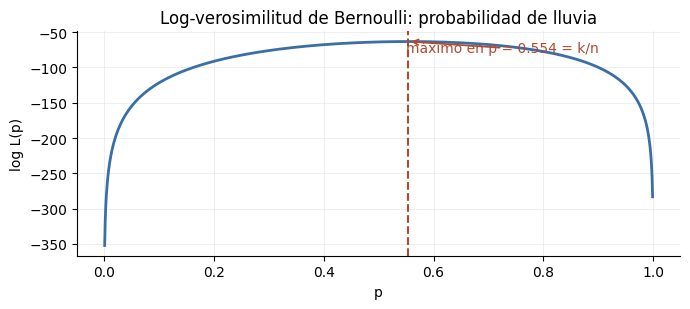

In [25]:
ll = log_lik(grilla, k, n)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(grilla, ll, color=AZUL, lw=2)
ax.axvline(p_grilla, color=ROJO, ls="--", lw=1.5)
ax.annotate(f"máximo en p = {p_grilla:.3f} = k/n",
            xy=(p_grilla, ll.max()), xytext=(0.55, ll.max() - 15),
            color=ROJO,
            arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.2))
ax.set_xlabel("p")
ax.set_ylabel("log L(p)")
ax.set_title("Log-verosimilitud de Bernoulli: probabilidad de lluvia")
eje_limpio(ax)
plt.tight_layout()
plt.show()

### Ejercicio 7 (0.20): MLE de la Normal

Sobre `temperature_2m_max`: (a) `mu_hat` sin usar `.mean()`. (b) `sigma2_hat`, el promedio de las desviaciones al cuadrado. Comparar con NumPy.

In [26]:
temp = clima["temperature_2m_max"]

# a) mu_hat: el promedio, sin usar .mean()
mu_hat = temp.sum() / len(temp)

# b) sigma2_hat: promedio de (temp - mu_hat)**2
sigma2_hat = ((temp - mu_hat)**2).sum() / len(temp)

print(mu_hat, sigma2_hat)

# Verificación (descomentar):
assert np.isclose(mu_hat, temp.mean())
assert np.isclose(np.sqrt(sigma2_hat), temp.std(ddof=0))

26.85978260869566 3.6256651701323253


### Ejercicio 8 (0.20): MAP con un prior equivocado

Prior Beta(2, 10): la creencia de alguien que piensa que en Guatemala casi no llueve (1 día de lluvia en 10 imaginarios). Implementar `map_beta` y comparar con el MLE usando los 92 días.

$$\hat{p}_{MAP} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2}$$

In [27]:
def map_beta(k, n, a=2, b=10):
    return (k + a - 1)/(n + a + b - 2)

# comparar MLE y MAP con los 92 días
mle_92 = k / n

map_92 = map_beta(k, n)
print(f"MLE = {mle_92:.3f}   MAP (Beta(2,10)) = {map_92:.3f}")


# Verificación (descomentar):
assert round(map_beta(k, n), 3) == 0.510

MLE = 0.554   MAP (Beta(2,10)) = 0.510


### Ejercicio 9 (0.20): el prior se diluye

Para cada `m` en `[7, 14, 30, 60, 92]`: con los **primeros** `m` días, calcular `k_m`, el MLE, el MAP y la diferencia absoluta. Guardar `(m, mle_m, map_m)` en `resultados` e imprimir la tabla.

In [28]:
ns = [7, 14, 30, 60, 92]
resultados = []

for m in ns:
    k_m = int(clima["llovio"][:m].sum())
    mle_m = k_m / m
    map_m = map_beta(k_m, m)
    resultados.append((m, mle_m, map_m))
    print(f"m={m:3d}  k={k_m:2d}  MLE={mle_m:.3f}  MAP={map_m:.3f}  dif={abs(mle_m - map_m):.3f}")

# Verificación (descomentar):
difs = [abs(mle_m - map_m) for _, mle_m, map_m in resultados]
assert round(difs[0], 2) == 0.19 and round(difs[-1], 2) == 0.04

m=  7  k= 3  MLE=0.429  MAP=0.235  dif=0.193
m= 14  k= 4  MLE=0.286  MAP=0.208  dif=0.077
m= 30  k=14  MLE=0.467  MAP=0.375  dif=0.092
m= 60  k=38  MLE=0.633  MAP=0.557  dif=0.076
m= 92  k=51  MLE=0.554  MAP=0.510  dif=0.045


### Ejercicio 10 (0.20): graficar la dilución

Con `resultados`: graficar MLE y MAP contra `m` (dos series con leyenda). El patrón está en el notebook de la sesión 5.

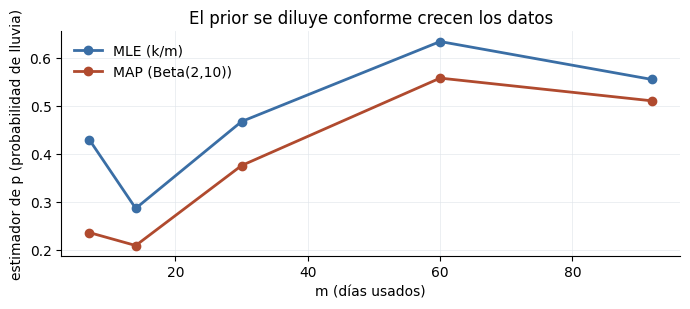

In [29]:
ms = [r[0] for r in resultados]
mles = [r[1] for r in resultados]
maps_ = [r[2] for r in resultados]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ms, mles, color=AZUL, marker="o", lw=2, label="MLE (k/m)")
ax.plot(ms, maps_, color=ROJO, marker="o", lw=2, label="MAP (Beta(2,10))")
ax.set_xlabel("m (días usados)")
ax.set_ylabel("estimador de p (probabilidad de lluvia)")
ax.set_title("El prior se diluye conforme crecen los datos")
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

## Parte C · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

El prior Beta(2,10) era objetivamente malo para época lluviosa. En 3-4 líneas, **citando los números del ejercicio 9**: ¿qué hicieron los datos con ese prior, a partir de cuántos días dejó de dominar, y qué implica esto para usar regularización (ridge/lasso) en modelos con pocos datos?

_(Responder editando esta celda)_

**Respuesta:** Con m=7 días, el prior domina: el MLE da 0.43, mientras que el MAP queda en 0.24, con una diferencia de 0.19. Conforme aumentan los datos, esa diferencia baja pasando de 0.19 hasta llegar a una diferencia de solo 0.04, haciendo que para m=92 el prior ya casi no domina. Para ridge/lasso esto significa que, con pocos datos, la regularización puede pesar demasiado: ayuda si está bien elegida, pero puede sesgar bastante si está mal calibrada; por eso hay que ajustar según la cantidad de datos.


## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- La IA se uso principalmente, para resolver pequeñas dudas con atributos, temas de los valores del diccionario, asi como la estructura correcta para hacer las gráficas. Finalmente también se aprovecho para realizar prints mucho más bonitos. En el ejercicio 3 se realizó el inciso c había dudas  lluvia máxima. La IA ayuda a encontrar los atributos .loc y .idxmax, que sirvió para encontrar el valor máximo y usarlo. En el ejercicio 4, se utilizó para resolver dudas con los valores del diccionario, pues algunos si se puedieron resolver basandose el los notebooks de clase, pero otros aún generaban dudas, asi que la IA se usó como confirmación de los valores a colocar, principalmente en los relacionadas con fechas, las demás si se pudieron deducir sin IA. Finalmente lo que objetivamente más me costó es la realización de las gráficas, por lo que la IA se uso principalmente para enterder bien los elementos del codigo para generarlas, entender bien para que sirve cada linea del código y lograr asociar las graficas de los notebooks de clase con las de estos ejercicios.  